In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Python environment ready")
print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)

print("\nPyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python environment ready
Project root: C:\Users\tscou\capstone
Raw data folder: C:\Users\tscou\capstone\data\raw

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


In [2]:
file_path = RAW_DATA_DIR / "all_tickets_processed_improved_v3.csv"

print("Dataset path:", file_path)
print("File exists:", file_path.exists())

df = pd.read_csv(file_path)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Dataset path: C:\Users\tscou\capstone\data\raw\all_tickets_processed_improved_v3.csv
File exists: True

Rows: 47837
Columns: 2

Column names:
['Document', 'Topic_group']


In [3]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 14.5 MB


In [5]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Document       0
Topic_group    0
dtype: int64

Duplicate rows:
0


In [6]:
class_counts = df["Topic_group"].value_counts()

print("Number of classes:", df["Topic_group"].nunique())
print("\nClass counts:")
print(class_counts)

Number of classes: 8

Class counts:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [7]:
class_percentages = (
    df["Topic_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

Topic_group
Hardware                 28.47
HR Support               22.82
Access                   14.89
Miscellaneous            14.76
Storage                   5.81
Purchase                  5.15
Internal Project          4.43
Administrative rights     3.68
Name: proportion, dtype: float64


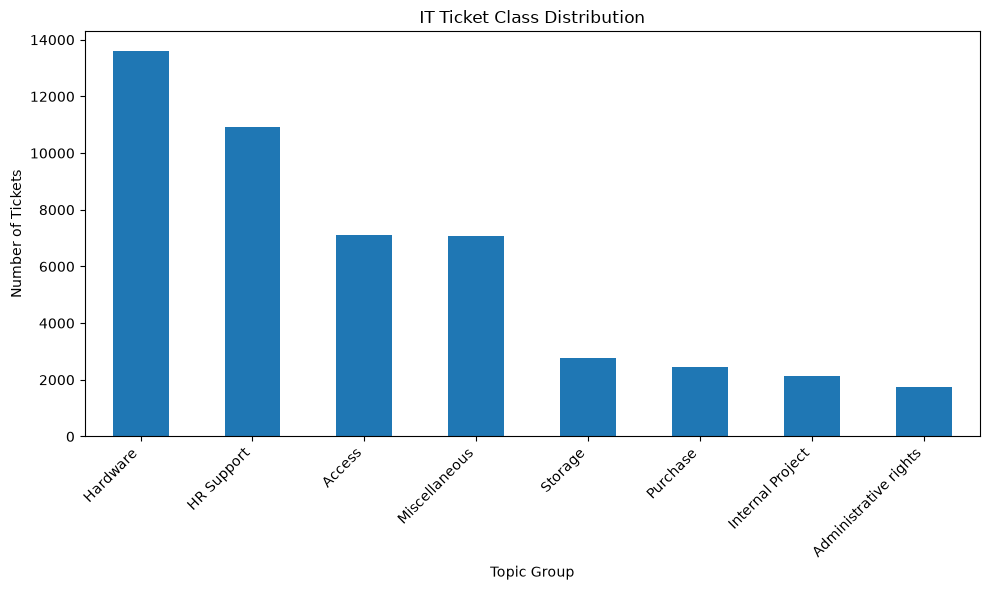

In [8]:
plt.figure(figsize=(10, 6))

class_counts.plot(kind="bar")

plt.title("IT Ticket Class Distribution")
plt.xlabel("Topic Group")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [9]:
df["char_count"] = df["Document"].astype(str).str.len()
df["word_count"] = df["Document"].astype(str).str.split().str.len()

df[["Document", "Topic_group", "char_count", "word_count"]].head()

,Document,Topic_group,char_count,word_count
0,connection with icon icon dear please setup ic...,Hardware,111,18
1,work experience user work experience user hi w...,Access,124,19
2,requesting for meeting requesting meeting hi p...,Hardware,93,14
3,reset passwords for external accounts re expir...,Access,948,145
4,mail verification warning hi has got attached ...,Miscellaneous,115,15


In [10]:
from sklearn.model_selection import train_test_split

X = df["Document"]
y = df["Topic_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38269
Testing samples: 9568


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            max_features=50000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [12]:
import time

start = time.perf_counter()

baseline_model.fit(X_train, y_train)

train_time = time.perf_counter() - start

print("Training time:", round(train_time, 2), "seconds")

Training time: 10.07 seconds


In [13]:
start = time.perf_counter()

y_pred = baseline_model.predict(X_test)

inference_time = time.perf_counter() - start

print("Inference time:", round(inference_time, 2), "seconds")

Inference time: 0.48 seconds


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8518
Macro Precision: 0.838
Macro Recall: 0.8747
Macro F1: 0.854

Classification Report:
                       precision    recall  f1-score   support

               Access       0.90      0.88      0.89      1425
Administrative rights       0.69      0.86      0.76       352
           HR Support       0.89      0.84      0.86      2183
             Hardware       0.85      0.81      0.83      2724
     Internal Project       0.80      0.93      0.86       424
        Miscellaneous       0.79      0.86      0.82      1412
             Purchase       0.93      0.90      0.92       493
              Storage       0.86      0.93      0.89       555

             accuracy                           0.85      9568
            macro avg       0.84      0.87      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



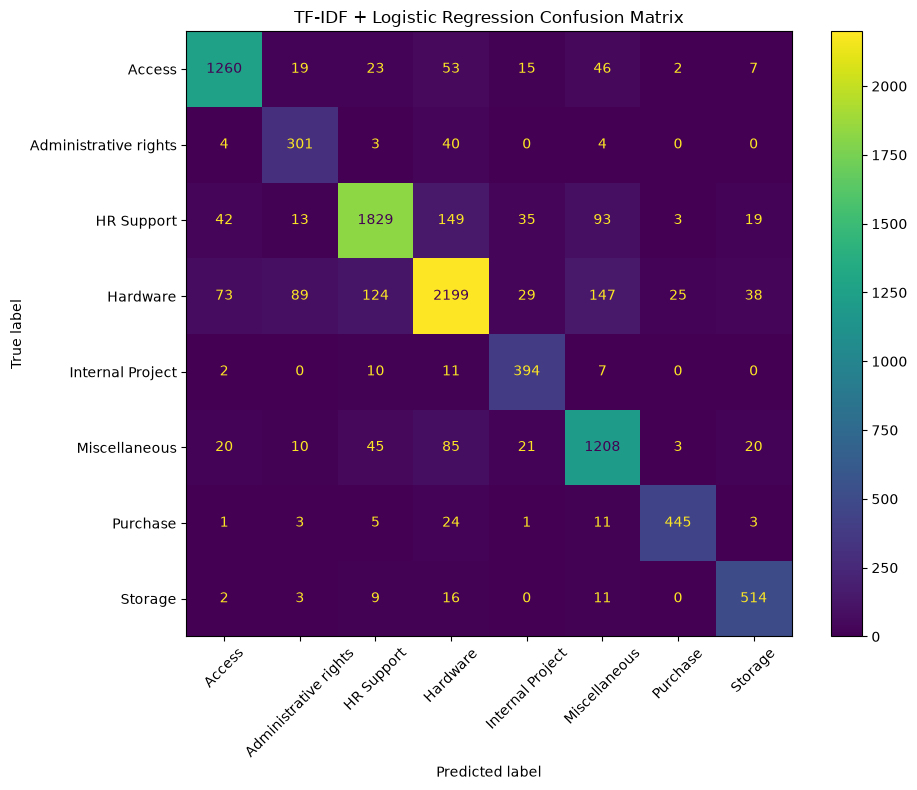

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Macro Precision": [macro_precision],
    "Macro Recall": [macro_recall],
    "Macro F1": [macro_f1],
    "Training Time Seconds": [train_time],
    "Inference Time Seconds": [inference_time]
})

baseline_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time Seconds,Inference Time Seconds
0,TF-IDF + Logistic Regression,0.851798,0.838036,0.874745,0.854048,10.070032,0.481942


In [17]:
results_file = RESULTS_DIR / "model_comparison.csv"

baseline_results.to_csv(
    results_file,
    index=False
)

print("Saved results to:")
print(results_file)

Saved results to:
C:\Users\tscou\capstone\results\model_comparison.csv
